# Agents, Uncertainty, and Decisions

## Basic Notions

### Agents

An agent is an autonomous entity that observes aspect of its environment and that can choose to perform certain actions on it. Examples for this include:

1. An investor who observes the investment market to choose which investment to perform.
2. A medical researchers who observes the efficacy of known drugs to choose the number of patients to enroll in a clinical study for a new drug.
3. A vehicle that observes its sensor inputs to decide whether or not to change the driving direction or speed.

**Central question of this course**: how can an agent
1. decide on what action it should perform in an uncertain environment and 
2. improve with experience (as more and more observations are made)?

In this module we will mainly focus on the first question. The second question will then be discussed in the main part of this course, before we turn to specific agent types in the last part.

### Environments

The environment of an agent is (the relevant part of) the world in which the agents finds itself in---not only at the time of the decision but also its relevant past and future.
For instance, in the above examples, the environments might be defined as:

1. The earnings and share prices of a set of public companies across all of their lifetime (i.e., until they go bankrupt)
2. The efficacy of all potential drugs on all potential patients of the corresponding disease
3. The driving history of the vehicle including its position, velocity, and acceleration, along with all objects it encountered in its vicinity

We can see that the environment of an agent can be very complex, though in practice we might only represent the most important aspects of it. As an abstract symbol for a concrete environment, we use the greek lowercase letter $\omega$ ("omega"). This is derived from the word "outcome" as in the concrete *outcome* of an experiment.

Importantly, the agent does not know its concrete environment, only that it is one out of a set of possible environments, which we denote by the capital greek $\Omega$. 

### Actions and Decisions

We assume that the agent can choose an action from an action set $A$. This action set can be finite or infinite (countable or uncountable). For example:

1. Invest a fixed budget into one of $k$ financial assets, $a_1, \dots, a_k$: $A=\{a_1, \dots, a_k\}$
2. Choose the number of patients to enroll in a clinical trial: $A=\{1, 2, \dots\}$
3. Reset driving direction and acceleration of a car: $A=\{(a_\mathrm{dir}, a_\mathrm{acc}) \, : \, \delta_\mathrm{dir} \in [-1, 1], a_\mathrm{acc} \in [-1, 1]\}$

In order to decide on what action to choose, the agent needs some sort of *preference* of what to achieve in the world. We assume that these preference are given in the form of a real-valued **loss function** $\ell$. The semantic of $\ell$ that the agent wants to choose an action that incurs as little loss as possible. Further, the suitability of an action clearly depends on the environment. Hence, $\ell$ takes two inputs: an environment $\omega \in \Omega$ and an action $a \in A$ and its output $\ell(\omega, a)$ is the loss incurred by action $a$ in environment $\omega$.

### Simple Example: Investment

Assume an agent can choose to invest $\$1000$ either in

1. **Action $a_1$:** bonds of a company that return $\$1500$ in two years if the company did not go bankrupt (outcome $\omega_1$) or nothing if it did ($\omega_2$); or
2. **Action $a_2$:** a safe investment that surely returns $\$1300$ 

This situation results in the loss function $\ell(\omega, a)$ given by the following table:

$\ell$ | $a_1$ | $a_2$ 
:---  | ---: | ---: 
$\omega_1$ | -500 | -300 
$\omega_2$ | 1000 | -300 

**Which action should the agent choose?**

Clearly, the answer depends on what is reasonable to *believe* about the outcome. 

## Beliefs and Uncertainty

### Aleatoric and Epistemic Uncertainty

In typical environments, agents face two different kinds of uncertainty: 

1. Non-deterministic mechanisms.
    
    Relates to the data / observations recorded by the agent (e.g., through noisy measurement devices) as well as to the outcome of actions.

    Called **aleatoric uncertainty** from Latin *alea* for "die" as in the famous quote of Suetonius to Iulius Ceasar *alea iacta est* ("the die is cast/thrown") at the start of the Roman civil war.

    Example: outcome of next player's dice roll in Backgammon

    Characteristic: can *not* be reduced by collecting more data / observations

2. Lack of knowledge. 

    Relates to quantities in the world that are principally deterministic, just not known to the agent. 
    
    Called **epistemic uncertainty** from Greek *epsisteme* for "knowledge".

    Example: location of Uganda on a map of Africa

    Characteristic: can typically be reduced by appropriate data collection and processing (more on that later)

<table style="margin-left: auto; margin-right: auto;">
  <tr>
    <td align="center">
      <img src="images/snake_eyes_dice.jpg" height="200">
    </td>
    <td align="center">
      <img src="images/africa.jpg" height="200">
    </td>
  </tr>
  <tr style="text-align: center;">
    <td><b>Aleatoric Uncertainty</b><br>(Outcome of die roll)</td>
    <td><b>Epistemic Uncertainty</b><br>(Location of Uganda)</td>
  </tr>
</table>

**Question:** For each of the following facts/quantities, discuss whether there are aleatoric and/or epistemic uncertainties.

1. The capital of Kazakhstan
2. The position of an electron orbiting an atomic core
3. The outcome of a spin of a roulette wheel
4. The distance to another car driving in front of an autonomous vehicle
5. The net worth of a specific company in two years
6. The net worth of a specific company ten years ago


### Events

What makes an environment uncertain is that there is a number of potential states that it could be in---at least from the perspective of the agent at the time of inquiry.
Therefore, it makes sense to mathematically model such an environment as a collection of all those possible states.
These states are typically called "outcomes" as in "outcome of an experiment".
Correspondingly, one typically uses the greek capital letter $\Omega$ (Omega) to denote the set of all possible outcomes/states and the non-capital version $\omega$ to denote an individual outcome/state.
The set of outcomes is called **sample space**.

For example:

1. The sample space corresponding to the possible outcomes of rolling two six-sided dice is $\Omega=\{(a, b): a,b \in \{1, 2, 3, 4, 5, 6\}\}$.
2. The sample space corresponding to the Uganda question is the set of all the marked regions on the given map of Africa.

While an outcome/state involves all uncertain elements in an environment, we often want to focus on specific (binary) questions of interest.
For Example:

1. Will the sum of dice roles be 5? 
2. Does Uganda have a border with the lake of Victoria?

As we can see, the answer to such questions can be "yes" not only for one, but for a subset of outcomes/states of the sample space. Such a subset $F \subseteq \Omega$ is called an **event**. For example, the event corresponding to the first example question above is $$F=\{(a, b): a+b=5\}=\{(1, 4), (2, 3), (3, 1), (4, 1)\} \enspace .$$

The set of all events that an agent could consider in an environment is called the **event space** and is often denoted by a calligraphic $\mathcal F$. There is a number of assumptions about the event space:

1. **Closed under complementation**: For every event $F \in \mathcal{F}$ also its **complement**, i.e., the set difference $\Omega \setminus F$ is an event in $\mathcal{F}$. This means that for every proposition that the agent could consider it could also consider its negation (e.g., "will the sum of dice roles not be equal to five").

2. **Closed under unions**: if sets $F_1, F_2, \dots \in \mathcal{F}$ then also their union $F_1 \cup F_2 \cup \dots$ is an event in $\mathcal{F}$. This means that every sequence of propositions that the agent could consider it could also consider their disjunction (e.g., "will the sum of the dice roles be equal to five or will the two dice show an equal number of eyes").

3. **Non-triviality**: there is at least one event $F \in \mathcal{F}$, which implies with the other two axioms in particular that the complete sample space $\Omega$ is in $\mathcal{F}$.

By the way: A family of subsets $\mathcal{F}$ that satisfies the above requirements is called a **sigma algebra**.

### St. Petersburg Games and Infinity

Assume an agent is offered the following game to play for 100 dollars: a fair coin (with sides "Heads"/"Tails") will be thrown until it lands on Tails (T) and then the agent will receive $2^k$ dollars where $k$ is the number of times the coin was thrown. This is the so-called **St. Petersburg Game**, which we will investigate later in more detail in the context of utility functions. 

As this and many other related examples show is that we want to accommodate for infinite sample spaces. For instance, we could define the sample space as $\Omega=\{1, 2, \dots \}=\mathbb{N}$ the set of natural numbers (positive integers) corresponding to the number of times the coin is flipped. In other contexts it makes more sense to define the sample space as the set of all possible infinite sequences

$$\omega = (\omega_1, \omega_2, \omega_3, \dots)$$

where $\omega_n \in \{H, T\}$.

### Probability

Probability spaces are the abstract mathematical model of uncertainty / randomness over a range of possible outcomes. A probability space consists of a sample space $\Omega$ and an event space $\mathcal{F}$ as defined above and additionally a **probability measure** $\Pr: \mathcal F \to [0, 1]$ that quantifies how certain or "probable" the occurrence of an event is.  

For example for the sample space of two dice roles, assuming both dice are fair we have $$\Pr(\{(1, 1)\})=\Pr(\{(1, 2)\})=\dots=1/36$$.

<div align="center">
    <img src="images/dice_measure.png" width="500">
</div>

Similarly to the sigma-algebra, also the probability measure is assumed to satisfy some properties (axioms):

1. Unity: $\Pr(\Omega)=1$, meaning it is certain that some outcome will occur
2. Additivity: for events $E_1, E_2, \dots \in \mathcal F$ that are mutually exclusive, i.e., $E_i \cap E_j = \emptyset$ the probabilities add up, i.e., $$\Pr(E_1 \cup E_2 \cup \dots)=\Pr(E_1)+\Pr(E_2)+\dots$$  
    For example, for the fair dice rolls scenario, this axiom implies that $\Pr(F_\mathrm{even\,sum})=1/2$.

From these, other properties follow logically, most importantly

3. Complement: $\Pr(\Omega \setminus F)=1-\Pr(F)$
4. Monotonicity: for events $A \subseteq B$, it holds that $\Pr(A) \leq \Pr(B)$
5. for events $A$ and $B$, it holds that $\Pr(A \cap B) = \Pr(A \cup B) - \Pr(A) - \Pr(B)$

### Interpretation of Probabilities

There are at least two interpretations of abstract probabilities when modeling uncertain quantities, whether in the real world or in an artificial environment of an agent.

1. Frequentist interpretation where probabilities describe the limiting frequencies of event occurrences under infinite repetitions of an experiment, i.e., $$\Pr(E) = \lim_{n \to \infty} \frac{\# \text{repetitions where }E\text{ occured}}{n}$$

2. Bayesian interpretation where probabilities reflect degrees of beliefs of an agent about an uncertain quantity, i.e., $\Pr(A) < \Pr(B)$ means that the agent beliefs $A$ is relatively less likely to occur (or to be the case) than $B$.

It is relatively straightforward to see that limiting event frequencies of repeatable experiments yield probabilities for which the properties discussed above hold.
In contrast, it may seem that the relative likelihoods captured in an agent's believe could lead to quite different numerical quantifications---or that there is no numerical measure that would faithfully represent certain relative orders of beliefs.

However, it turns out that ``rationally'' ordered beliefs as captured in the following set of axioms inadvertently lead to probabilities that define the axioms above (see DeGroot):

1. **Completeness:** For any two events, $A$ and $B$ the agent either beliefs $A$ is more likely than $B$, $B$ is more likely than $A$, or both are equally likely.

2. **Transitivity:** If the agent beliefs that $A$ is more or equally likely than $B$ and that $B$ is more or equally likely than $C$, then the agent also beliefs that $A$ is more or equally likely than $C$.

3. **Monotonicity and non-triviality:** For any event $A$, is equally or more likely than the event $\emptyset$ of no outcome and equally or less likely than the event of any outcome $\Omega$. Further, $\emptyset$ is believed to be less likely than $\Omega$.

4. **Continuity:** If there is a sequence of events $A_1, A_2, A_3, ...$ of decreasing believed likelihood such that each of them is believed to be more likely than some event $B$, then also the limit $\bigcap_{i=1}^\infty$ is believed to be more likely than $B$.

5. **Granularity**: For every event $A$ and every positive integer $n$, there exists a sequence of events $E_1, E_2, \dots, E_n$ such that for any number $n$, the agent can partition the sample space $S$ into $2^n$ disjoint events, each of which the agent considers equally likely.

### Random Variables

## Belief-based Decisions

Equipped with the concept of probabilities and their Bayesian interpretation, we can now define the **belief of an agent**, most generally, as probability function on the probability space $(\Omega, \mathcal{F})$ of the possible environments. However, usually it is enough to define a belief more simply as the joint distribution, e.g., in the form of the joint cdf $P$, of a number of random variables $Z_1, Z_2, \dots, Z_k$.

We postpone the two central question of 

1. what different beliefs an agent can actually hold (that is the question of the belief or **probability model**) and 
2. how to arrive at a reasonable belief based on observations of the environment (that is the topic of **inference**).

Instead we focus now on how to choose an action once a belief has been formed.

### Decisions based on Expected Loss

Now assume that an agent has a belief about the environment captured in the joint probability distribution with cdf $P$ of a random vector $Z=(Z_1, \dots, Z_k)$ that contains all quantities relevant for the definition of the loss function that we can then write as $\ell(Z, a)$. A straightforward decision principle is then to choose an action $a$ based on its **expected loss** $L(a)$:

$$
L(a) = \mathbb{E}(\ell(Z, a))=\int_z \ell(z, a) \mathrm d P(z) = \int_{z_1} \dots \int_{z_k} \ell(z, a) \mathrm d P(z_k) \dots \mathrm d P(z_k) \enspace .
$$

In particular, if it exists, one can choose an action $a^*$ of minimal expected loss, i.e.,
$$
L(a^*) = \min \{L(a) \! : \, a \in A\}
$$

An extension of this simple criterion (that takes into account observations to form belief) will be called **Conditional Bayesian Decision Principle** (Berger, 1985, Ch. 1.5.1) or simply **Maximum Expected Utility Principle** (Kochenderfer, 2022, Ch. 6.4). As we will discuss in due time, there are other  criteria that can lead to very different decisions.

### Simple Example Revisited

Recall our example in which an agent can choose to invest $\$1000$ either in

1. **Action $a_1$:** bonds of a company that return $\$1500$ in two years if the company did not go bankrupt or nothing if it did; or
2. **Action $a_2$:** a safe investment that surely returns $\$1300$ 

Let us define a binary variable $Z$ that indicates whether the company goes bankrupt in the next two years, i.e.,
$$
Z =
\begin{cases}
1 &, \text{if company goes bankrupt}\\
0 &, \text{otherwise}
\end{cases} \enspace .
$$

With this we can rewrite the loss function as

$$
\begin{aligned}
\ell(Z, a_1)&=1000\,Z - 500\,(1-Z)\\
\ell(Z, a_2)&=-300
\end{aligned}\enspace .
$$

Since $Z$ is a binary variable it is governed by a Bernoulli distribution, say with parameter $\theta$, i.e.,
$$
Z \sim \mathrm{Ber}(\theta) \enspace .
$$
That means that $\theta = \Pr(Z=1)$ is the degree to which the agent beliefs that the company will go bankrupt.

**Questions:**

1. Assuming the agent is completely undecided whether bankruptcy will occur ($\theta=0.5$), what is the expected loss of $L(a_1)$ of action $a_1$?
2. Further in this case, which action would the agent choose according to the expected loss decision principle?
3. For what values of $\theta$ will the agent choose what action (determine graphically)?

$$
\begin{aligned}
L(a_1) &= (-500)\,\theta+(1-\theta)\, 1000 = 1000 - 1500\,\theta\,\\
L(a_2) &= -300
\end{aligned}
$$

[[-500 -300]
 [1000 -300]]


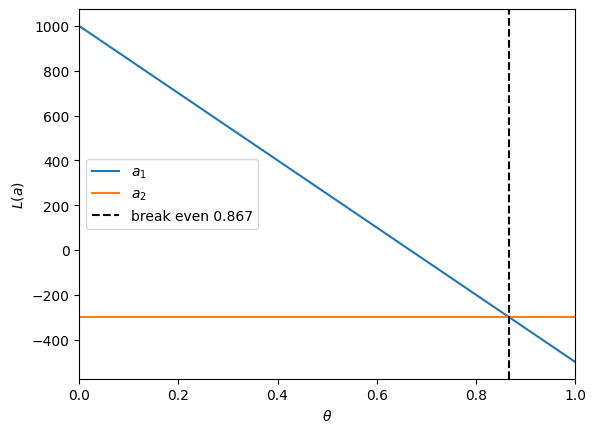

In [ ]:
from matplotlib import pyplot as plt
import numpy as np

loss_matrix = np.array([[-500, -300], [1000, -300]])
print(loss_matrix)

def expected_loss(a, theta):
    return loss_matrix[0, a]*theta + (1-theta)*loss_matrix[1, a]

thetas = np.linspace(0, 1, 200)
plt.plot(thetas, expected_loss(0, thetas), label='$a_1$')
plt.plot(thetas, expected_loss(1, thetas), label='$a_2$')
plt.axvline(13/15, linestyle='--', color='k', label=f'break even at {13/15:.3f}')
plt.xlabel(r'$\theta$')
plt.ylabel('$L(a)$')
plt.legend()
plt.margins(x=0)
plt.show()

## Scenario: Production Volume

### Setting and Loss Function

A company has to decide on a relative production volume $a \in [0, 1]$ for a new product. Here, $a$ is the fraction of a known market size $s$ of product units, i.e., the overall number of units for which there is a demand on the market. This means that choosing production volume $a$ corresponds to producing $sa$ units of the product. 

The *markup* of the product, i.e., the ratio of profit (selling price - cost) to cost is assumed to be $0.5$.

**Question: What aspect of the environment / random variable does the utility/loss of an action $a \in A=[0, 1]$ depend on?**

The *market capture* of the new product $Z \in [0, 1]$ describing the number of units $sZ$ that will be sold at the determined price.

**Question: What is a reasonable loss function in terms of $z \in [0, 1]$ and $a \in [0, 1]$?**

Hints:

1. Consider the loss separately for the two cases of under-production $a \leq z$ and over-production $a > z$.
2. You can simplify the function by considering as loss the differences between the optimal action and the action chosen.

Answer:
$$
\ell(z, a) =
\begin{cases}
z - a & \text{, } z \geq a \\
2(a - z) & \text{, otherwise} 
\end{cases}
$$

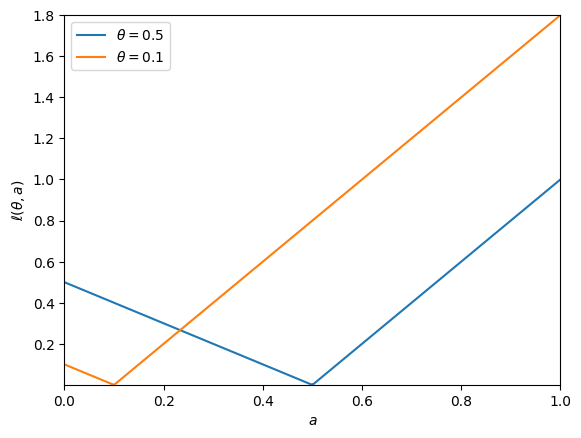

In [32]:
from matplotlib import pyplot as plt
import numpy as np

def loss(theta, a):
    return (theta >= a)*(theta - a) + (theta < a)*2*(a - theta)

xs = np.linspace(0, 1, 200, endpoint=True)
plt.plot(xs, loss(0.5, xs), label=r'$\theta=0.5$')
plt.plot(xs, loss(0.1, xs), label=r'$\theta=0.1$')
plt.xlabel('$a$')
plt.ylabel(r'$\ell(\theta,a)$')
plt.margins(x=0, y=0)
plt.legend()
plt.show()

### Expected Loss

Using the definition of our loss function, we can decompose the Bayesian expected loss as
$$
\begin{aligned}
L(a) &= \bold{E}(\ell(\theta, a))\\
&= \bold{E}(\theta - a \mid \theta \geq a)\Pr(\theta \geq a) + \bold E(2(a-\theta) \mid \theta < a)\Pr(\theta < a) \enspace .
\end{aligned}
$$

Let us assume we believe $\theta \sim \mathrm{Unif}(0.1, 0.2)$. Then we can further analyse the above expression via a case distinction on $a$. 

**Case $a < 0.1$**: 

This case is simple, because it implies $\Pr(\theta \geq a)=1$, $\Pr(\theta < a)=0$, and $\bold{E}(\theta \mid \theta \geq a)=\bold E(\theta)=0.15$. If follows that $L(a)=0.15 - a$.

**Case $a > 0.2$**:

This case is similarly simply, because it implies $\Pr(\theta \geq a)=0$, $\Pr(\theta < a)=1$, and again $\bold{E}(\theta \mid \theta < a)=\bold E(\theta)=0.15$. It follows that $L(a)=2(a - \bold E(\theta \mid a > \theta))=2a - 0.3$.

**Case $0.1 \leq a \leq 0.2$**:

This final case is a bit more complicated, but still managable. 

1. $\Pr(\theta \geq a) = 10(0.2 - a)$
2. $\Pr(\theta < a) = 10(a - 0.1)$
3. $\Pr(\theta \mid \theta \geq a) = (0.2 - a)/2$
4. $\Pr(\theta \mid \theta < a)=(a - 0.1)/2$

It follows that 
$$
\begin{aligned}
L(a) &= 5(0.2 - a)^2 + 10(a-0.1)^2\\
&= 5a^2 + 0.2 - 2a + 10a^2 + 0.1 - 2a\\
&= 15a^2 - 4a + 0.3
\end{aligned}
$$

Summarising the three different cases yields:
$$
L(a) =
\begin{cases}
0.15 - a & \text{, } a < 0.1\\
15a^2 - 4a + 0.3 & \text{, } 0.1 \leq a \leq 0.2\\
2a - 0.3 & \text{, otherwise}
\end{cases}
$$

Further, with basic calculus we can show that the optimal action is $a^*=2/15$ with a Bayesian expected loss of $L(a^*)=1/30$

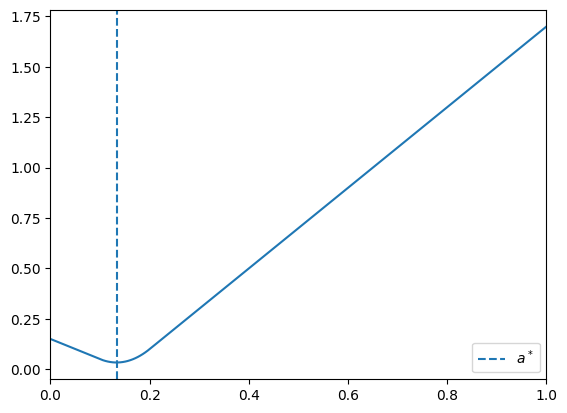

In [33]:
def bayes_expected_loss(a):
    return (0.15-a)*(a<0.1) + (15*a**2 - 4*a + 0.3)*((a >= 0.1) & (a<= 0.2)) + (2*a-0.3)*(a>0.2)

plt.plot(xs, bayes_expected_loss(xs))
plt.axvline(2/15, ls='--', label='$a^*$')
plt.margins(x=0)
plt.legend()
plt.show()